# TO DO (URGENT)
1. CURRENLTY p=1 FIXED (DUE TO ONE-STEP PREDICTION ONLY) - FIX IT LATER
2. NEW LOSS: A. MAG EIG = 1, B. DIST BTW MODE MAXIMIZE
3. Fix the testing part = number is wrong

# TO DO (OPTIONAL, LATER)
1. RESOLVE DECODER LIMITATION? HIDDEN_K SHOULD BE QUITE SMALL THAN NOW

Libraries

In [1]:
import os
import sys
sys.path.append('/dataset/')
sys.path.append("../src_re") 

import math
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.utils import parameters_to_vector
from scipy.linalg import eig, inv
from torch.utils.tensorboard import SummaryWriter
from torch.nn.utils.stateless import functional_call
from tensorboard import notebook
from datetime import datetime
from tqdm import tqdm

# KAE
from Autoencoder import KoopmanAutoencoder
from Autoencoder_functions import *

# Cartpole
from test_cartpole_function import *
from models.MLP import CartpoleMLP


Parameters

In [2]:
# Use GPU
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cuda:0')
print('Currently using... '+str(device))

# Load pre-trained KAE?
load_model = False
load_model_name = 'Your_model_name.pt'

# KAE parameters
hidden_k = 4 # observable dim
kae_size = 4 # size of KAE
kae_coef = 0.75
lr_kae = 1e-2
num_epochs = 1000
training_data_size = 10000 # size of training dataset
batch_size = 512 # 128
c1, c2, c3 = 1, 1, 1 # KAE loss parameters
p = 1 # KAE prediction step
padded_dimension = 5 # MUST BE BIGGER THAN ANY STATE DIMENSION (INPUT, OUPTUT, INTERNAL)

# Cartpole parameters
original_model_name = 'ppo_cartpole_policy.pt'
state_bound_lo = torch.tensor([-4.8, -10, -0.418, -3.0], device=device) # pos, vel, angle, angluar vel
state_bound_hi = torch.tensor([ 4.8,  10,  0.418,  3.0], device=device) # pos, vel, angle, angluar vel
env = gym.make("CartPole-v1")
num_episodes = 20 # test number for validation
max_reward = 500 # possible maximum reward
reward_margin = max_reward*0.01 # allow this much reward decrease

# INitialization
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n
task_coef = 1-kae_coef
Info = [kae_coef, hidden_k, 'CARTPOLE_v1']
l = padded_dimension
print('obs dim: '+str(obs_dim) + ' / act dim: '+str(act_dim))
if padded_dimension < obs_dim or padded_dimension < act_dim:
    print('ERROR, PADDED DIMENSION MUST BE BIGGER')
    exit()

original_model = CartpoleMLP(obs_dim, act_dim).to(device)

Currently using... cuda:0
obs dim: 4 / act dim: 2


Fixed parameters & Initialization

In [3]:
## Set training to be deterministic
seed = 10
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(seed)

## LOAD TRAINED MODEL
if os.path.isfile('../saved_models_re/originals/'+original_model_name):
    state_dict = torch.load('../saved_models_re/originals/'+original_model_name, weights_only=True, map_location=device)
    original_model.load_state_dict(state_dict)
    print('load '+original_model_name)
    
    # TEST PERFORMANCE OF LOADED MODEL
    print('testing model')
    test_cartpole_function('../saved_models_re/originals/'+original_model_name, save_imgs=False)

else:
    print('ERROR, NO MODEL FOUND')

## GENERATE RANDOM SAMPLE FOR KAE TRAINING
# LOAD existing dataset
if os.path.isfile('results/Cartpole_KAE_training_samples_'+str(int(training_data_size))+'.pth'):
    data_dict = torch.load('results/Cartpole_KAE_training_samples_'+str(int(training_data_size))+'.pth', map_location=device)
    training_data = data_dict['training_data']
else:
    training_data = []
    for i in range(training_data_size):
        random_input = torch.rand(1, obs_dim, device=device) * (state_bound_hi - state_bound_lo) + state_bound_lo
        outputs = original_model(random_input)
        
        pad_in = torch.ones(random_input.size(0), l - obs_dim, device=device)
        pad_out = torch.ones(outputs.size(0), l - act_dim, device=device)
        aug_input = torch.cat([random_input, pad_in], dim=1)
        aug_output = torch.cat([outputs, pad_out], dim=1)

        # Save snapshot
        training_data.append((aug_input.detach().cpu(), aug_output.detach().cpu()))

    # Save the generated training data
    torch.save({'training_data': training_data}, 'results/Cartpole_KAE_training_samples_'+str(int(training_data_size))+'.pth')

## Build KAE
state_dim = padded_dimension
kae = KoopmanAutoencoder(state_dim=state_dim, hidden_dim=kae_size, observable_dim = hidden_k, device=device).to(device)
kae.train()
criterion_kae = koopman_loss
mse = torch.nn.MSELoss()
optimizer_kae = optim.Adam(kae.parameters(), lr=lr_kae)
kae.train()


a_all = torch.stack([a for (a, b) in training_data])  # shape: (len(data), 1, 5)
b_all = torch.stack([b for (a, b) in training_data])  # shape: (len(data), 1, 5)

print('Training data shape: ',a_all.shape, b_all.shape)

load ppo_cartpole_policy.pt
testing model
Average reward over 20 episodes: 500.0
Rewards per episode: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]
Tanh ver
Training data shape:  torch.Size([10000, 1, 5]) torch.Size([10000, 1, 5])


Wandb

In [4]:
# # Connect wandb
# current_date = datetime.now().strftime("%Y-%m-%d")

# wandb.init(project="Koopman_decomposition",
#            name = str(current_date),
#            config={
#             "lr_kae": lr_kae,
#             "lr_classifier": lr_classifier,
#             "num_epochs": num_epochs,
#             "batch_size": batch_size,
#             "p": p,
#             "c1": c1,
#             "c2": c2,
#             "c3": c3,
#             "target_dataset": target_dataset,
#             "hidden_c": hidden_c,
#             "training_data_size": training_data_size,
#             "original_classifier_epoch": original_classifier_epoch
#     })

Main training

In [5]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from Autoencoder import *
from Autoencoder_functions import *
from test_cartpole_function import *

## Preprocess KAE train data
train_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
aug_input_all = torch.cat([training_data[i][0].unsqueeze(0) for i in range(len(training_data))])
aug_output_all = torch.cat([training_data[i][1].unsqueeze(0) for i in range(len(training_data))])

# Load model
if load_model:
    kae = torch.load('results/kae_'+load_model_name, weights_only=False, map_location=device)
    kae.to(device)
    print('model loaded')

# Or train new one
elif not load_model:
    best_reward = 0.0
    for epoch in (tq_var := tqdm(range(num_epochs), desc="Training")):
        running_loss = 0.0
        running_classifier_loss = 0.0

        # Each batch
        for inner, (aug_input, aug_output) in enumerate(train_loader):
            # print(aug_input.shape, aug_output.shape)
            loss_task = 0.0
            loss_kae = 0.0

            # KAE loss
            loss_kae, z = compute_l_kae(kae, aug_input, aug_output, c1, c2, c3, p, device) # Koopman operator is updated here.
            
            # Task loss
            loss_task = compute_l_task(kae, aug_input_all, aug_output_all, mse)

            # Total loss
            loss = kae_coef * loss_kae + task_coef * loss_task

            # Update           
            optimizer_kae.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(kae.parameters(), max_norm=1.0)  # Add this line here
            optimizer_kae.step()
            running_loss = running_loss + loss.detach().cpu().item()

            # prof.step()

        # Wandb
        # wandb.log({
        #     "epoch": epoch,
        #     "train_loss": running_loss,
        #     "lr": optimizer_kae.param_groups[0]['lr']
        # })
        
        current_date = datetime.now().strftime("%Y-%m-%d") 
        waypoint_name = 'waypoints/waypoint_'+str(Info)+f'_{current_date}.pth'
        file_name = 'waypoints/KAE_'+str(Info)+f'_{current_date}.pth'

        # THIS SUPPOSES TO BE A VALIDATION SET #################
        reward = test_cartpole_kae_function(kae, hidden_k, padded_dimension, device, mode_number = -1, num_episodes = num_episodes)
        kae.train()

        if float(reward) > best_reward or float(reward >= max_reward-reward_margin):
            torch.save({
            'epoch': epoch,
            'param_kae': kae.state_dict(),
            'optimizer_state_dict': optimizer_kae.state_dict(),
            'ko': kae.K,
            'Info': Info
            }, waypoint_name)
            torch.save(kae, file_name)
            best_reward = reward
            print(f'Best reward updated (Avg. of {num_episodes}): {best_reward:.4f} at epoch {epoch}')

        avg_loss = running_loss / len(train_loader)
        tq_var.set_description(f'Epoch [{epoch+1:4d}/{num_epochs}] | Loss: {avg_loss:.6f} | loss_kae: {loss_kae:.6f} | loss_task: {loss_task:.6f}')

        if math.isnan(running_loss/len(train_loader)):
            print('NAN detected')
            break
            
    current_date = datetime.now().strftime("%Y-%m-%d")
    waypoint_name = 'results/waypoint_'+str(Info)+'_'+str(epoch+1)+f'_{current_date}.pth'
    file_name = 'results/KAE_'+str(Info)+'_'+str(epoch+1)+f'_{current_date}.pth'
    torch.save({
    'epoch': epoch,
    'param_kae': kae.state_dict(),
    'optimizer_state_dict': optimizer_kae.state_dict(),
    'ko': kae.K,
    'Info': Info
    }, waypoint_name)
    torch.save(kae, file_name) # save final model
    print(f'Iteration finished, loss = {running_loss/len(train_loader):.4f}')

    # wandb.finish()


Training:   0%|          | 0/1000 [00:00<?, ?it/s]/home/joonwon/github/Koopman_decompose_ext/KAE/Autoencoder_functions.py:120: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3725.)
  eigvals = eigvals.conj().T
Epoch [   1/1000] | Loss: 456.977187 | loss_kae: 472.048553 | loss_task: 437.002319:   0%|          | 1/1000 [00:19<5:19:58, 19.22s/it]

Best reward updated (Avg. of 20): 500.0000 at epoch 0


Epoch [   2/1000] | Loss: 428.012775 | loss_kae: 426.184692 | loss_task: 411.603546:   0%|          | 2/1000 [00:38<5:18:57, 19.18s/it]

Best reward updated (Avg. of 20): 500.0000 at epoch 1


Epoch [   3/1000] | Loss: 404.290883 | loss_kae: 391.783203 | loss_task: 388.673035:   0%|          | 3/1000 [00:57<5:18:10, 19.15s/it]

...

Best reward updated (Avg. of 20): 500.0000 at epoch 80


Epoch [  85/1000] | Loss: 6.594905 | loss_kae: 6.441740 | loss_task: 1.568420:   8%|▊         | 85/1000 [20:58<3:26:38, 13.55s/it] 

Best reward updated (Avg. of 20): 500.0000 at epoch 84


Epoch [  85/1000] | Loss: 6.594905 | loss_kae: 6.441740 | loss_task: 1.568420:   8%|▊         | 85/1000 [21:05<3:46:59, 14.88s/it]


KeyboardInterrupt: 

In [ ]:
# load_model_name = "KAE_[0.75, 64, 'MNIST_DEEP']_1000_2025-08-25.pth"
# kae = torch.load('results/'+load_model_name, weights_only=False, map_location=device)
# kae.to(device)
# print('model loaded')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Original model
Average reward over 20 episodes: 500.0
Rewards per episode: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]
Koopman Autoencoder (reconstruction)
GIF saved as imgs/cartpole_all_episodes_subplots_with_time_mode_-1.gif
337.75
Koopman Autoencoder mode: 0
GIF saved as imgs/cartpole_all_episodes_subplots_with_time_mode_0.gif
323.65
Koopman Autoencoder mode: 1
GIF saved as imgs/cartpole_all_episodes_subplots_with_time_mode_1.gif
500.0
Koopman Autoencoder mode: 2
GIF saved as imgs/cartpole_all_episodes_subplots_with_time_mode_2.gif
9.25
Koopman Autoencoder mode: 3
GIF saved as imgs/cartpole_all_episodes_subplots_with_time_mode_3.gif
9.35


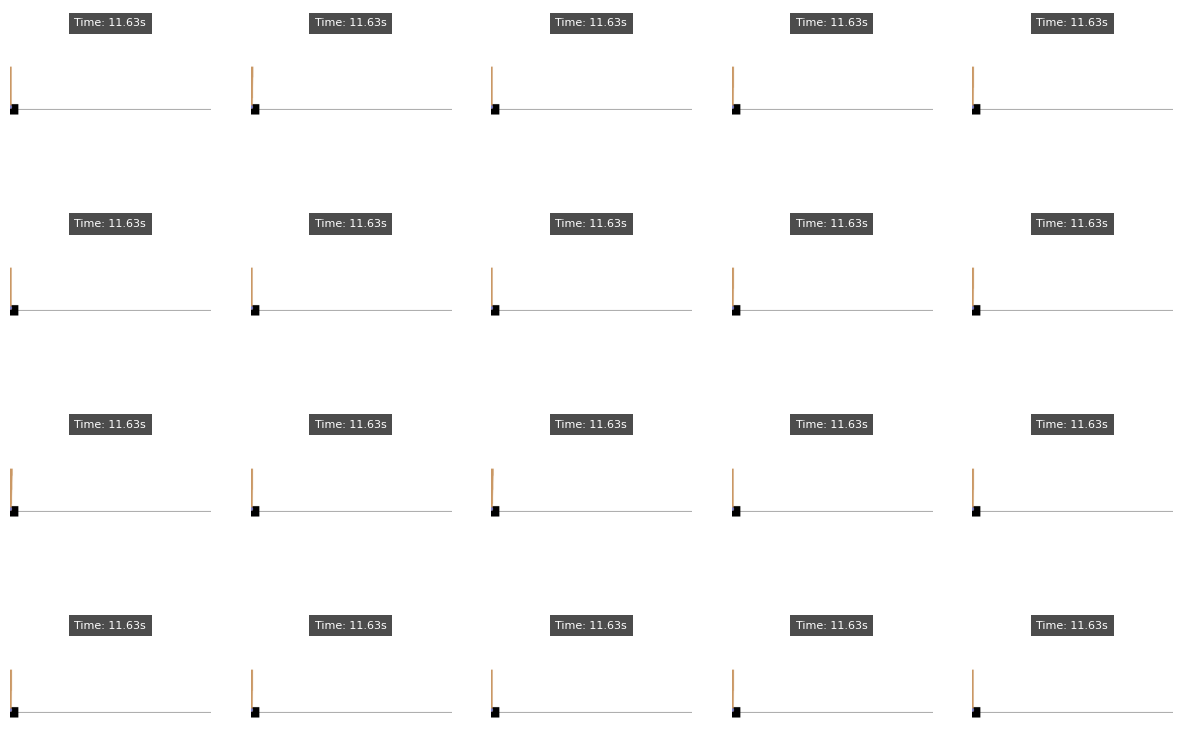

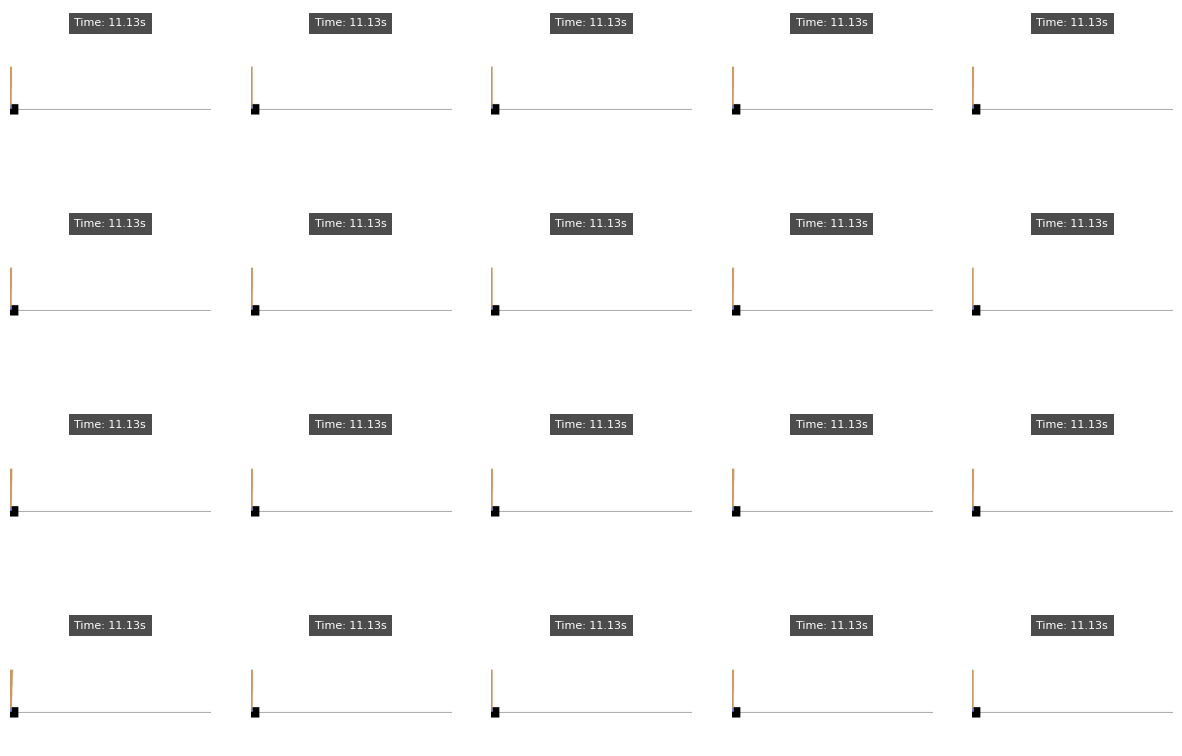

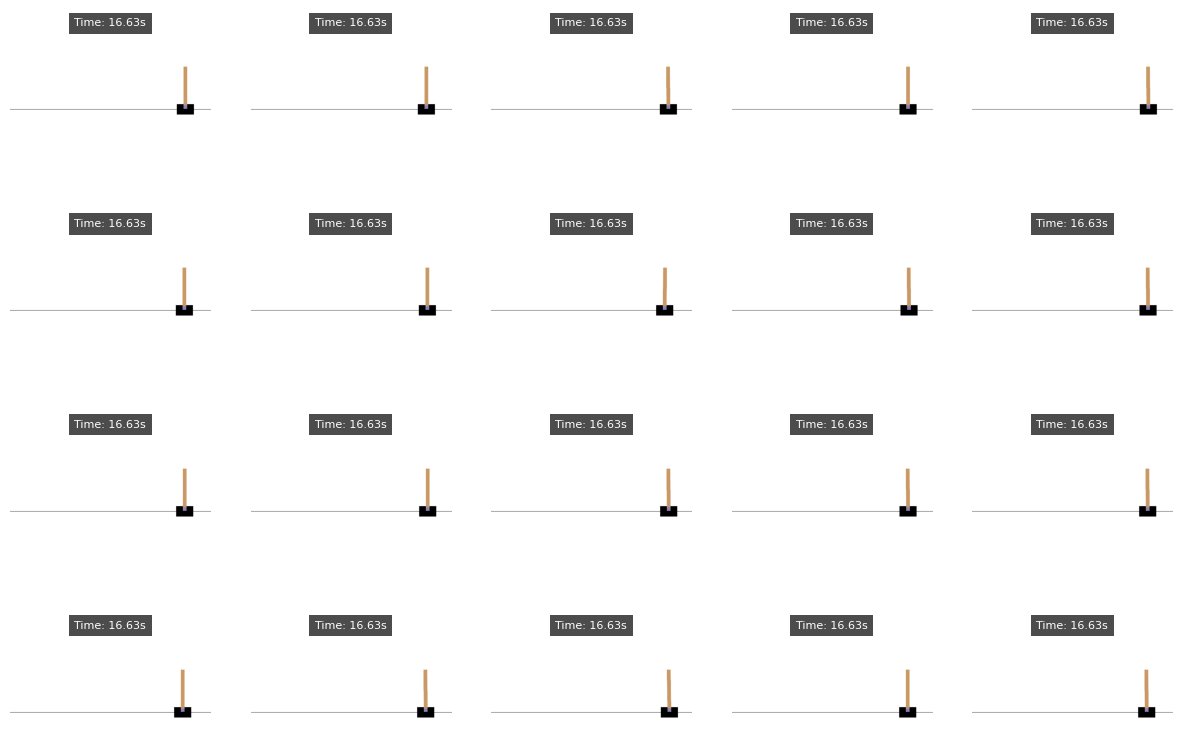

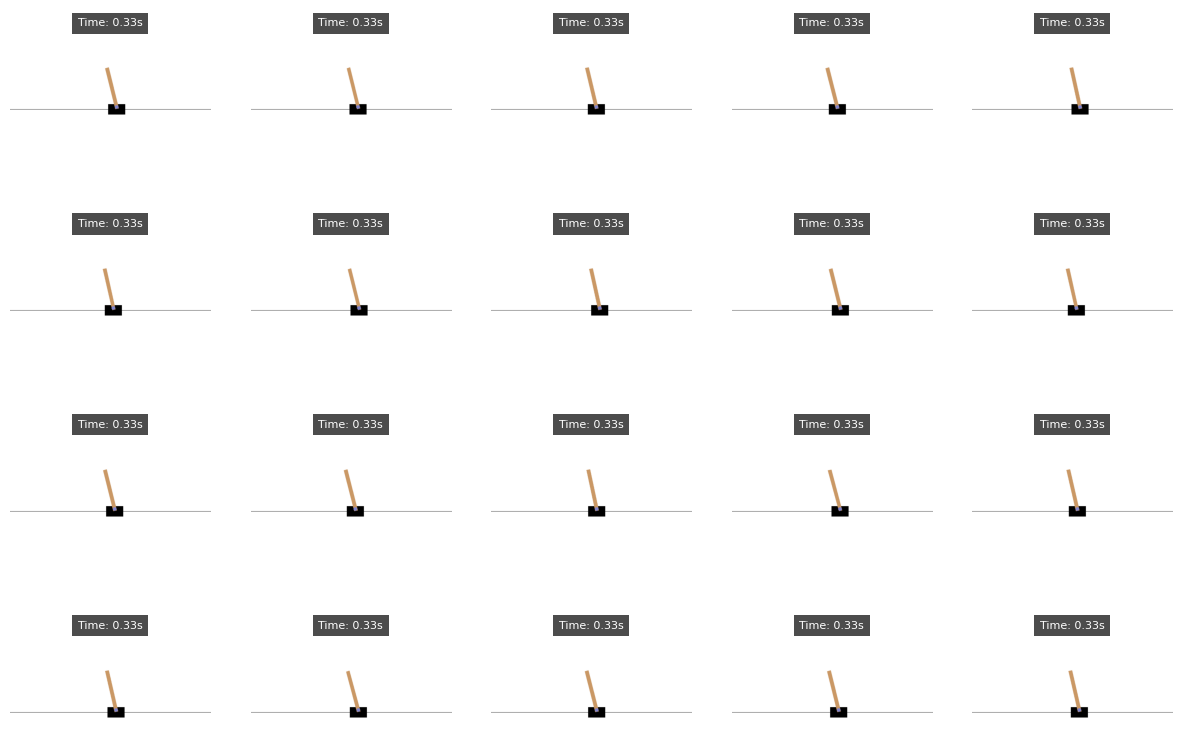

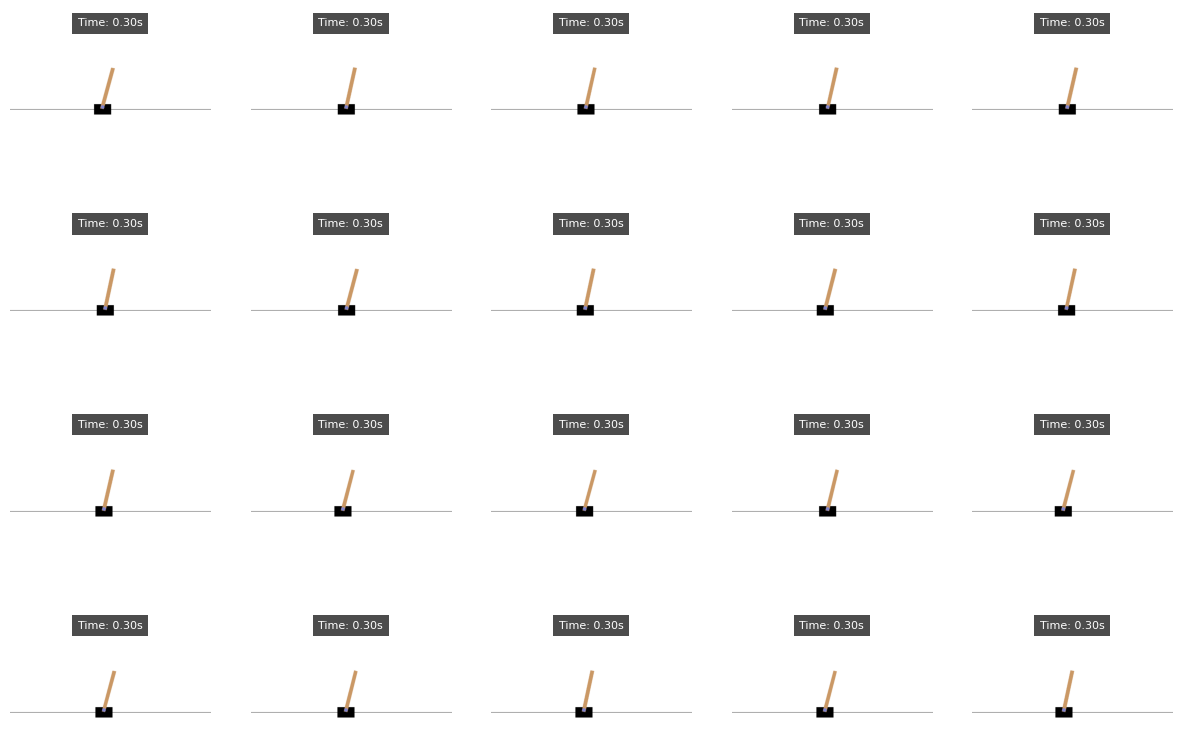

In [7]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from Autoencoder import *
from Autoencoder_functions import *
from test_cartpole_function import *

## CHECK RECONSTRUCTION AND MODE PERFORMANCE

print('Original model')
test_cartpole_function('../saved_models_re/originals/'+original_model_name, save_imgs=False)

with torch.no_grad():
    kae.eval()
    print('Koopman Autoencoder (reconstruction)')
    reward = test_cartpole_kae_function(kae, hidden_k, padded_dimension, device, mode_number = -1, num_episodes = num_episodes, save_imgs = True)
    print(reward)

    for i in range(0,hidden_k):
        print('Koopman Autoencoder mode: '+str(i))
        reward = test_cartpole_kae_function(kae, hidden_k, padded_dimension, device, mode_number = i, num_episodes = num_episodes, save_imgs = True)
        print(reward)

In [ ]:
## UNDER CONSTRUCTION BELOW ###############################

import importlib
from Autoencoder_functions import *

%load_ext autoreload
%autoreload 2

sorted_labels, sorted_indices = torch.sort(all_test_labels)
all_test_images_sorted = all_test_images[sorted_indices]
all_test_labels_sorted = sorted_labels
per_label_test_images = {i: all_test_images[all_test_labels == i] for i in range(num_classes)}
per_label_test_labels = {i: all_test_labels[all_test_labels == i] for i in range(num_classes)}

with torch.no_grad():
    for j in range(0,hidden_k):
        result = []
        for cc in range(0,num_classes):
            reconstructed_output_wo_pad = []
            # reconstructed_output_prop_wo_pad = []
            for i in range(0,len(per_label_test_images[cc])):
                _,z,_ = kae(all_test_images[i,:])
                z_next = torch.matmul(z, kae.K.T)
                reconstructed_output = stt_decompose_mode(kae, z, z_next, hidden_k, j, propagation=True)
                reconstructed_output_wo_pad.append(reconstructed_output[:num_classes])

            reconstructed_output_wo_pad = torch.stack(reconstructed_output_wo_pad)
            reconstructed_output_wo_pad_real = reconstructed_output_wo_pad.real.detach()
            predicted = torch.argmax(reconstructed_output_wo_pad_real, dim=1)
            # print(np.shape(reconstructed_output), np.shape(reconstructed_output_wo_pad))
            correct = (predicted == per_label_test_labels[cc]).sum().item()
            total = all_test_labels.size(0)
            accuracy = 100.0 * correct / total
            result.append(accuracy)
        print(str(j)+"-th mode "+str(result))


In [ ]:

print()

predicted = torch.argmax(reconstructed_output_wo_pad, dim=1)
print(np.shape(reconstructed_output), np.shape(reconstructed_output_wo_pad))
print(np.shape(predicted))
correct = (predicted == all_test_labels).sum().item()
total = all_test_labels.size(0)
accuracy = 100.0 * correct / total
print(accuracy)

In [ ]:

    for idx_modes in tqdm(range(kae_size)):
        temp = np.zeros(num_classes)
        
        for idx_sub in range(num_classes):
            param_sub = param_sub_all[:, idx_modes]
            if target_dataset == 'MNIST_DEEP':
                classifier_sub_test = deepdeeper_MLP(image_size, hidden_c, num_classes).to(device)
            else:   
                classifier_sub_test = deeper_MLP(image_size, hidden_c, num_classes).to(device)
            classifier_sub_test.eval()
            nn.utils.vector_to_parameters(param_sub, classifier_sub_test.parameters())
            testloader = dataset_in_use_per_class.sub_testloaders[idx_sub]
            total = 0
            correct = 0
            for images, labels in testloader:
                images = images.reshape(-1, 28*28).to(device)
                labels = labels.to(device)
                outputs = classifier_sub_test(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            accuracy = 100 * correct / total
            temp[idx_sub] = accuracy
        formatted = np.array([num for num in temp])

        if idx_modes == 0:
            formatted_history = formatted
        else:
            formatted_history = np.vstack((formatted_history, formatted))

# Get best element
formatted_history2 = np.array(formatted_history, dtype=float)
bests = np.max(formatted_history2,axis = 0)
is_max = formatted_history2 == bests
row_counts = np.sum(is_max, axis = 1)

print('Best elements :')
print(bests)
print('Best counts :')
print(row_counts)

num_cols = formatted_history2.shape[1]
for col in range(num_cols):
    rows_with_max = np.where(formatted_history2[:,col] == bests[col])[0]
    print('------------')
    print(f'Class {col}: Best = {bests[col]}')
    for row_idx in rows_with_max:
        print(f'Mode {row_idx}: [|eig|={torch.linalg.norm(eigvals_d[row_idx])}] {np.array2string(formatted_history2[row_idx], precision=4)}')